
# NASA CMAPSS FD002 — 최고점 노트북 (사용자 데이터 로드 방식 유지 버전)
*(Dual-Model: CNN+BiLSTM+Attention + Transformer, Optuna HPO, Submission Stabilization, Asymmetric(NASA) Scoring 포함)*

이 노트북은 **당신의 `1. Nasa2단계_1.ipynb`에서 쓰던 데이터 로드 방식/컬럼명**을 그대로 유지하면서,
최고점 파이프라인(클러스터 정규화 + 듀얼모델 + Optuna + 안정화 + 비대칭 스코어 분석)을 결합한 버전입니다.

> Kaggle에서는 `DATA_DIR="/kaggle/input/nasa-cmaps"`만 맞추면 바로 실행됩니다.


In [1]:

# =====================
# 0) Setup
# =====================
import os, gc, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
print("OK")


OK


In [2]:

# (필요시) 설치
import sys, subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import optuna
    print("optuna:", optuna.__version__)
except:
    pip_install("optuna>=3.6.0")
    import optuna
    print("optuna:", optuna.__version__)

try:
    import plotly
except:
    pip_install("plotly>=5.0.0")


optuna: 4.7.0


In [3]:

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF:", tf.__version__)


TF: 2.20.0



## 1) 데이터 불러오기 (당신의 문서 방식 그대로)

- `DATA_DIR`
- `TRAIN_FILE / TEST_FILE / RUL_FILE`
- `col_names`
- `read_cmapss_txt()`


In [4]:
import os
import pandas as pd

DATA_DIR = r"C:\Users\yuzhd\Desktop\유진\data\CMaps"

TRAIN_FILE = "train_FD002.txt"
TEST_FILE  = "test_FD002.txt"
RUL_FILE   = "RUL_FD002.txt"

train_path = os.path.join(DATA_DIR, TRAIN_FILE)
test_path  = os.path.join(DATA_DIR, TEST_FILE)
rul_path   = os.path.join(DATA_DIR, RUL_FILE)

col_names = (
    ["unit_number", "time_in_cycles"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

def read_cmapss_txt(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=r"\s+", header=None, names=col_names)
    df = df.dropna(axis=1, how="all")
    return df

train_df = read_cmapss_txt(train_path)
test_df  = read_cmapss_txt(test_path)
rul_df   = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])

print(train_df.shape, test_df.shape, rul_df.shape)
train_df.head()


(53759, 26) (33991, 26) (259, 1)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286



## 2) Train RUL 만들기 (당신의 방식)

Train은 각 엔진(unit)이 고장날 때까지 기록되어 있으므로:

`RUL = (unit별 마지막 cycle) - (현재 cycle)`


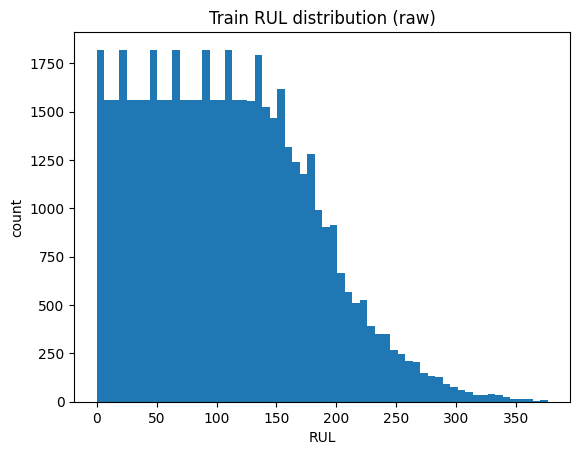

,unit_number,time_in_cycles,RUL
0,1,1,148
1,1,2,147
2,1,3,146
3,1,4,145
4,1,5,144


In [5]:

# unit별 마지막 cycle
train_last_cycle = train_df.groupby("unit_number")["time_in_cycles"].max().rename("max_cycle")
train_df = train_df.merge(train_last_cycle, on="unit_number", how="left")
train_df["RUL"] = train_df["max_cycle"] - train_df["time_in_cycles"]
train_df.drop(columns=["max_cycle"], inplace=True)

plt.figure()
plt.hist(train_df["RUL"], bins=60)
plt.title("Train RUL distribution (raw)")
plt.xlabel("RUL"); plt.ylabel("count")
plt.show()

train_df[["unit_number","time_in_cycles","RUL"]].head()



## 3) Test 마지막 시점 RUL 정답(분석/점수 계산용)

CMAPSS 제공 `RUL_FD002.txt`는 **test 엔진별 마지막 관측 시점에서 남은 수명** 입니다.
(Leaderboard 제출에는 정답이 없다고 가정하지만, 여기서는 분석/Asymmetric scoring 비교를 위해 사용)


In [6]:

rul_at_last = rul_df.copy()
rul_at_last["unit_number"] = np.arange(1, len(rul_at_last) + 1)

# test 엔진별 마지막 관측 cycle
test_last_cycle = test_df.groupby("unit_number")["time_in_cycles"].max().rename("last_cycle")
test_last = test_df.merge(test_last_cycle, on="unit_number", how="left")
test_last = test_last[test_last["time_in_cycles"] == test_last["last_cycle"]].copy()

test_last = test_last.merge(rul_at_last, on="unit_number", how="left")
print(test_last.shape)
test_last[["unit_number","time_in_cycles","RUL"]].head()


(259, 28)


,unit_number,time_in_cycles,RUL
0,1,258,18
1,2,55,79
2,3,165,106
3,4,86,110
4,5,148,15



## 4) Asymmetric Scoring (NASA score) + contribution 분석


In [7]:

def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    d = y_pred - y_true
    score = 0.0
    for di in d:
        if di < 0:
            score += math.exp(-di/13.0) - 1.0
        else:
            score += math.exp(di/10.0) - 1.0
    return score

def nasa_score_contrib(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    d = y_pred - y_true
    contrib = np.zeros_like(d, dtype=float)
    for i, di in enumerate(d):
        if di < 0:
            contrib[i] = math.exp(-di/13.0) - 1.0
        else:
            contrib[i] = math.exp(di/10.0) - 1.0
    return d, contrib

print("sanity:", nasa_score([10,10],[10,10]), nasa_score([10,10],[0,0]), nasa_score([10,10],[20,20]))


sanity: 0.0 2.3162110678968917 3.43656365691809



## 5) 핵심 전처리: 운영조건 클러스터링 + 클러스터별 정규화 + (옵션) EWMA/rolling + low-variance drop

FD002는 운영 조건 모드가 여러 개라서 **op_setting_1~3 기반 클러스터링** 후,
각 클러스터별로 센서를 따로 스케일링하면 성능이 자주 좋아집니다.


In [8]:

sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
op_cols = [f"op_setting_{i}" for i in range(1, 4)]

def add_ewma(df, cols, alpha):
    out = df.copy()
    if alpha is None or alpha <= 0:
        return out
    out = out.sort_values(["unit_number","time_in_cycles"])
    for c in cols:
        out[c] = out.groupby("unit_number")[c].transform(lambda x: x.ewm(alpha=alpha, adjust=False).mean())
    return out

def add_rolling(df, cols, window):
    out = df.copy()
    if window is None or window <= 1:
        return out
    out = out.sort_values(["unit_number","time_in_cycles"])
    for c in cols:
        out[f"{c}_rm{window}"] = out.groupby("unit_number")[c].transform(lambda x: x.rolling(window, min_periods=1).mean())
        out[f"{c}_rs{window}"] = out.groupby("unit_number")[c].transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0.0))
    return out

def fit_preprocessor(train_split, hp, seed=SEED):
    tr = train_split.copy()
    tr["RUL"] = tr["RUL"].clip(0, hp["rul_cap"])

    kept = sensor_cols
    if hp["var_thr"] and hp["var_thr"] > 0:
        v = tr[kept].var()
        kept = v[v > hp["var_thr"]].index.tolist()

    tr = add_ewma(tr, kept, hp["ewma_alpha"])
    tr = add_rolling(tr, kept, hp["roll_w"])

    feat_cols = [c for c in tr.columns if (c in kept) or (c.startswith("sensor_") and ("_rm" in c or "_rs" in c))]
    feat_cols = sorted(feat_cols)

    km = KMeans(n_clusters=hp["n_clusters"], random_state=seed, n_init="auto")
    km.fit(tr[op_cols])
    tr_c = km.predict(tr[op_cols])

    scalers = {}
    for c in np.unique(tr_c):
        sc = StandardScaler()
        sc.fit(tr.loc[tr_c==c, feat_cols])
        scalers[int(c)] = sc

    return {"km": km, "scalers": scalers, "feat_cols": feat_cols, "kept_sensors": kept}

def transform_with_preprocessor(df, prep, hp):
    out = df.copy()
    if "RUL" in out.columns:
        out["RUL"] = out["RUL"].clip(0, hp["rul_cap"])

    out = add_ewma(out, prep["kept_sensors"], hp["ewma_alpha"])
    out = add_rolling(out, prep["kept_sensors"], hp["roll_w"])

    feat_cols = prep["feat_cols"]

    c = prep["km"].predict(out[op_cols])
    out["cluster"] = c

    for cl, sc in prep["scalers"].items():
        idx = (out["cluster"].values == cl)
        if idx.any():
            out.loc[idx, feat_cols] = sc.transform(out.loc[idx, feat_cols])

    return out



## 6) Windowing (sequence dataset)

- Train: 모든 가능한 window 생성(라벨 = window 마지막 시점 RUL)
- Test: 엔진별 **마지막 window**만 사용(submission)


In [9]:

def make_windows(df, feature_cols, seq_len=30, step=1, label_col="RUL", is_train=True):
    df = df.sort_values(["unit_number","time_in_cycles"])
    X, y, groups = [], [], []
    for u, g in df.groupby("unit_number"):
        g = g.reset_index(drop=True)
        feats = g[feature_cols].values.astype(np.float32)

        if is_train:
            labels = g[label_col].values.astype(np.float32)
            for start in range(0, len(g)-seq_len+1, step):
                end = start + seq_len
                X.append(feats[start:end])
                y.append(labels[end-1])
                groups.append(u)
        else:
            if len(g) < seq_len:
                pad = np.zeros((seq_len - len(g), feats.shape[1]), dtype=np.float32)
                window = np.vstack([pad, feats])
            else:
                window = feats[-seq_len:]
            X.append(window)
            groups.append(u)
    X = np.stack(X)
    groups = np.asarray(groups)
    if is_train:
        y = np.asarray(y).reshape(-1,1)
        return X, y, groups
    return X, groups

def unit_split(df, val_ratio=0.2, seed=SEED):
    units = df["unit_number"].unique()
    rng = np.random.RandomState(seed)
    rng.shuffle(units)
    n_val = max(1, int(val_ratio*len(units)))
    val_units = set(units[:n_val])
    tr = df[~df["unit_number"].isin(val_units)].copy()
    va = df[ df["unit_number"].isin(val_units)].copy()
    return tr, va



## 7) Model A: CNN + BiLSTM + Attention


In [10]:

class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(1,), initializer="zeros", trainable=True)
        super().build(input_shape)
    def call(self, x):
        e = tf.tensordot(x, self.W, axes=1) + self.b
        a = tf.nn.softmax(e, axis=1)
        context = tf.reduce_sum(x * a, axis=1)
        return context, tf.squeeze(a, axis=-1)

def build_model_a(input_shape, hp):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(hp["a_conv_filters"], hp["a_conv_kernel"], padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(hp["a_dropout"])(x)
    x = layers.Bidirectional(layers.LSTM(hp["a_lstm_units"], return_sequences=True))(x)
    x = layers.Dropout(hp["a_dropout"])(x)
    context, att = AttentionLayer(name="attention")(x)
    x = layers.Dense(hp["a_dense_units"], activation="relu")(context)
    x = layers.Dropout(hp["a_dropout"])(x)
    out = layers.Dense(1)(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(hp["lr"]),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse"), keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model



## 8) Model B: Transformer Encoder (time-series)


In [11]:

def transformer_encoder(x, hp):
    attn = layers.MultiHeadAttention(num_heads=hp["b_heads"], key_dim=hp["b_key_dim"], dropout=hp["b_dropout"])(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    ffn = layers.Dense(hp["b_ff_dim"], activation="relu")(x)
    ffn = layers.Dropout(hp["b_dropout"])(ffn)
    ffn = layers.Dense(x.shape[-1])(ffn)
    x = layers.Add()([x, ffn])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

def build_model_b(input_shape, hp):
    inp = keras.Input(shape=input_shape)  # (T,F)
    x = layers.Dense(hp["b_d_model"])(inp)

    pos = layers.Embedding(input_dim=hp["seq_len"], output_dim=hp["b_d_model"])
    positions = tf.range(start=0, limit=hp["seq_len"], delta=1)
    x = x + pos(positions)

    for _ in range(hp["b_layers"]):
        x = transformer_encoder(x, hp)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(hp["b_dropout"])(x)
    x = layers.Dense(hp["b_dense_units"], activation="relu")(x)
    x = layers.Dropout(hp["b_dropout"])(x)
    out = layers.Dense(1)(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(hp["lr"]),
        loss="mse",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse"), keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model



## 9) Optuna 튜닝: model_type(A/B)까지 포함

> 최고점 목표라면 `N_TRIALS`를 150~400+로 올려보세요.


In [12]:

from optuna.samplers import TPESampler

def build_datasets(train_split, valid_split, test_df, prep, hp):
    tr_t = transform_with_preprocessor(train_split, prep, hp)
    va_t = transform_with_preprocessor(valid_split, prep, hp)
    te_t = transform_with_preprocessor(test_df,    prep, hp)

    X_tr, y_tr, _ = make_windows(tr_t, prep["feat_cols"], seq_len=hp["seq_len"], step=hp["step"], is_train=True)
    X_va, y_va, _ = make_windows(va_t, prep["feat_cols"], seq_len=hp["seq_len"], step=hp["step"], is_train=True)
    X_te, g_te    = make_windows(te_t, prep["feat_cols"], seq_len=hp["seq_len"], step=1, is_train=False)
    return X_tr, y_tr, X_va, y_va, X_te, g_te

def train_eval_once(hp, model_type, seed=SEED, epochs=22, trial=None):
    tr_split, va_split = unit_split(train_df, val_ratio=0.2, seed=seed)
    prep = fit_preprocessor(tr_split, hp, seed=seed)
    X_tr, y_tr, X_va, y_va, _, _ = build_datasets(tr_split, va_split, test_df, prep, hp)

    if X_tr.shape[0] < 2000:
        raise optuna.TrialPruned()

    model = build_model_a(X_tr.shape[1:], hp) if model_type=="A" else build_model_b(X_tr.shape[1:], hp)

    cbs = [
        keras.callbacks.EarlyStopping(monitor="val_rmse", patience=5, mode="min", restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.5, patience=2, min_lr=1e-6, mode="min"),
    ]
    if trial is not None:
        cbs.append(optuna.integration.TFKerasPruningCallback(trial, monitor="val_rmse"))

    model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
              epochs=epochs, batch_size=hp["batch"], verbose=0, callbacks=cbs)

    va_pred = model.predict(X_va, batch_size=hp["batch"], verbose=0).reshape(-1)
    va_true = y_va.reshape(-1)
    rmse = math.sqrt(mean_squared_error(va_true, va_pred))
    ns = nasa_score(va_true, va_pred)
    return rmse, ns

def objective(trial):
    model_type = trial.suggest_categorical("model_type", ["A","B"])

    hp = {
        "rul_cap": trial.suggest_int("rul_cap", 95, 160),
        "n_clusters": trial.suggest_int("n_clusters", 2, 12),
        "seq_len": trial.suggest_int("seq_len", 20, 90),
        "step": trial.suggest_int("step", 1, 6),
        "ewma_alpha": trial.suggest_float("ewma_alpha", 0.0, 0.45),
        "roll_w": trial.suggest_int("roll_w", 1, 11),
        "var_thr": trial.suggest_float("var_thr", 0.0, 2e-3),
        "lr": trial.suggest_float("lr", 8e-5, 5e-3, log=True),
        "batch": trial.suggest_categorical("batch", [64,128,256]),
    }

    if model_type == "A":
        hp.update({
            "a_conv_filters": trial.suggest_categorical("a_conv_filters", [32,48,64,96,128,160]),
            "a_conv_kernel": trial.suggest_categorical("a_conv_kernel", [3,5,7]),
            "a_lstm_units": trial.suggest_categorical("a_lstm_units", [32,48,64,96,128,160]),
            "a_dense_units": trial.suggest_categorical("a_dense_units", [32,64,96,128,192,256]),
            "a_dropout": trial.suggest_float("a_dropout", 0.05, 0.45),
        })
    else:
        hp.update({
            "b_d_model": trial.suggest_categorical("b_d_model", [48,64,80,96,128,160]),
            "b_layers": trial.suggest_int("b_layers", 1, 4),
            "b_heads": trial.suggest_categorical("b_heads", [2,4,8]),
            "b_key_dim": trial.suggest_categorical("b_key_dim", [16,24,32]),
            "b_ff_dim": trial.suggest_categorical("b_ff_dim", [64,96,128,192,256,384]),
            "b_dense_units": trial.suggest_categorical("b_dense_units", [32,64,96,128,192,256]),
            "b_dropout": trial.suggest_float("b_dropout", 0.05, 0.45),
        })

    rmse, ns = train_eval_once(hp, model_type, seed=SEED, epochs=22, trial=trial)
    trial.set_user_attr("nasa_score", float(ns))
    return rmse

N_TRIALS = 50  # 최고점 목표면 150~400+ 권장
study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)
print("Best trial NASA:", study.best_trial.user_attrs.get("nasa_score"))


[I 2026-02-09 12:01:50,508] A new study created in memory with name: no-name-6c88b9fa-3363-4b18-9f17-fb214cd0719d
  0%|          | 0/50 [00:00<?, ?it/s]Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\yuzhd\miniconda3\envs\DS\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\yuzhd\miniconda3\envs\DS\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\yuzhd\miniconda3\envs\DS\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte
  0%|          | 0/50 [00:06<?, ?it/s]


[W 2026-02-09 12:01:57,211] Trial 0 failed with parameters: {'model_type': 'B', 'rul_cap': 143, 'n_clusters': 8, 'seq_len': 31, 'step': 1, 'ewma_alpha': 0.02613762547568976, 'roll_w': 10, 'var_thr': 0.0012022300234864176, 'lr': 0.001495214087812487, 'batch': 128, 'b_d_model': 128, 'b_layers': 2, 'b_heads': 2, 'b_key_dim': 32, 'b_ff_dim': 256, 'b_dense_units': 96, 'b_dropout': 0.3236932106048628} because of the following error: ModuleNotFoundError('\nCould not find `optuna-integration` for `tfkeras`.\nPlease run `pip install optuna-integration[tfkeras]`.').
Traceback (most recent call last):
  File "c:\Users\yuzhd\miniconda3\envs\DS\Lib\site-packages\optuna\integration\tfkeras.py", line 5, in <module>
    from optuna_integration.tfkeras import TFKerasPruningCallback
ModuleNotFoundError: No module named 'optuna_integration'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\yuzhd\miniconda3\envs\DS\Lib\site-packages\o

ModuleNotFoundError: 
Could not find `optuna-integration` for `tfkeras`.
Please run `pip install optuna-integration[tfkeras]`.

In [ ]:

# Optuna 시각화
try:
    import optuna.visualization as vis
    vis.plot_optimization_history(study).show()
    vis.plot_param_importances(study).show()
except Exception as e:
    print("Optuna vis error:", e)



## 10) 모델별 best(A/B)로 재학습 + Multi-seed + Dual Ensemble + Stabilization + Asymmetric scoring


In [ ]:

def best_trial_by_type(study, model_type):
    trials = [t for t in study.trials if t.state.name == "COMPLETE" and t.params.get("model_type")==model_type]
    if not trials:
        return None
    trials = sorted(trials, key=lambda t: t.value)
    return trials[0]

def fill_defaults_for_model(hp, model_type):
    defaults = dict(rul_cap=125, n_clusters=6, seq_len=50, step=1, ewma_alpha=0.2, roll_w=3, var_thr=0.0, lr=1e-3, batch=128)
    for k,v in defaults.items():
        hp.setdefault(k,v)
    if model_type=="A":
        for k,v in dict(a_conv_filters=64, a_conv_kernel=5, a_lstm_units=96, a_dense_units=128, a_dropout=0.2).items():
            hp.setdefault(k,v)
    else:
        for k,v in dict(b_d_model=96, b_layers=2, b_heads=4, b_key_dim=24, b_ff_dim=192, b_dense_units=128, b_dropout=0.2).items():
            hp.setdefault(k,v)
    return hp

def train_full_predict(train_df, test_df, hp, model_type, seed=SEED, epochs=140):
    # monitor용 unit split
    tr_split, va_split = unit_split(train_df, val_ratio=0.15, seed=seed)
    prep = fit_preprocessor(tr_split, hp, seed=seed)

    # datasets
    tr_t = transform_with_preprocessor(tr_split, prep, hp)
    va_t = transform_with_preprocessor(va_split, prep, hp)
    te_t = transform_with_preprocessor(test_df,  prep, hp)

    X_tr, y_tr, _ = make_windows(tr_t, prep["feat_cols"], seq_len=hp["seq_len"], step=hp["step"], is_train=True)
    X_va, y_va, _ = make_windows(va_t, prep["feat_cols"], seq_len=hp["seq_len"], step=hp["step"], is_train=True)
    X_te, g_te    = make_windows(te_t, prep["feat_cols"], seq_len=hp["seq_len"], step=1, is_train=False)

    model = build_model_a(X_tr.shape[1:], hp) if model_type=="A" else build_model_b(X_tr.shape[1:], hp)

    cbs = [
        keras.callbacks.EarlyStopping(monitor="val_rmse", patience=10, mode="min", restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.5, patience=3, min_lr=1e-6, mode="min"),
    ]
    hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                     epochs=epochs, batch_size=hp["batch"], verbose=0, callbacks=cbs)

    va_pred = model.predict(X_va, batch_size=hp["batch"], verbose=0).reshape(-1)
    va_true = y_va.reshape(-1)

    rmse = math.sqrt(mean_squared_error(va_true, va_pred))
    ns   = nasa_score(va_true, va_pred)

    te_pred = model.predict(X_te, batch_size=hp["batch"], verbose=0).reshape(-1)

    return {"model": model, "prep": prep, "history": hist.history,
            "val_rmse": rmse, "val_nasa": ns, "test_pred": te_pred, "test_units": g_te}

tA = best_trial_by_type(study, "A")
tB = best_trial_by_type(study, "B")

hpA = {} if tA is None else {k:v for k,v in tA.params.items() if k!="model_type"}
hpB = {} if tB is None else {k:v for k,v in tB.params.items() if k!="model_type"}
hpA = fill_defaults_for_model(hpA, "A")
hpB = fill_defaults_for_model(hpB, "B")

print("hpA keys:", list(hpA.keys())[:10], " ...")
print("hpB keys:", list(hpB.keys())[:10], " ...")


In [ ]:

# Multi-seed (선택) + 모델별 mean/median
USE_MULTI_SEED = True
SEEDS = [11, 22, 33]
EPOCHS_FINAL = 160

def train_multi_seed(model_type, hp):
    preds = []
    units_ref = None
    for sd in (SEEDS if USE_MULTI_SEED else [SEED]):
        seed_everything(sd)
        r = train_full_predict(train_df, test_df, hp, model_type=model_type, seed=sd, epochs=EPOCHS_FINAL)
        preds.append(r["test_pred"])
        units_ref = r["test_units"]
        print(f"{model_type} seed={sd} val_rmse={r['val_rmse']:.4f} val_nasa={r['val_nasa']:.2f}")
        gc.collect()
    preds = np.stack(preds)
    return preds.mean(axis=0), np.median(preds, axis=0), units_ref

predA_mean, predA_med, units = train_multi_seed("A", hpA)
predB_mean, predB_med, _     = train_multi_seed("B", hpB)
print("done", predA_mean.shape, predB_mean.shape)


In [ ]:

# Ensemble + Stabilization
def stabilize(pred, cap, rounding=False, qclip=None):
    x = pred.copy()
    if qclip is not None:
        lo, hi = np.quantile(x, qclip[0]), np.quantile(x, qclip[1])
        x = np.clip(x, lo, hi)
    if rounding:
        x = np.round(x)
    x = np.clip(x, 0, cap)
    return x

y_true_last = rul_at_last.sort_values("unit_number")["RUL"].values.astype(float)
cap = int(max(hpA["rul_cap"], hpB["rul_cap"]))

# weight grid + 안정화 조합 탐색 (분석용)
cands = []
for w in np.linspace(0,1,11):
    base = w*predA_mean + (1-w)*predB_mean
    for rounding in [False, True]:
        for qclip in [None, (0.01,0.99), (0.02,0.98)]:
            p = stabilize(base, cap=cap, rounding=rounding, qclip=qclip)
            rmse = math.sqrt(mean_squared_error(y_true_last, p))
            ns = nasa_score(y_true_last, p)
            cands.append((rmse, ns, w, rounding, qclip))
cands.sort(key=lambda x: x[0])
best_rmse, best_ns, best_w, best_round, best_qclip = cands[0]
print("BEST (RMSE-based):", cands[0])

pred_ens = best_w*predA_mean + (1-best_w)*predB_mean
pred_final = stabilize(pred_ens, cap=cap, rounding=best_round, qclip=best_qclip)

print("Final RMSE:", math.sqrt(mean_squared_error(y_true_last, pred_final)))
print("Final NASA:", nasa_score(y_true_last, pred_final))


In [ ]:

# Asymmetric score 분석 시각화
y_pred = pred_final
plt.figure()
plt.scatter(y_true_last, y_pred, s=10, alpha=0.6)
plt.title("Test(last-cycle): True vs Pred")
plt.xlabel("True RUL"); plt.ylabel("Pred RUL")
plt.plot([0,cap],[0,cap])
plt.show()

resid = y_pred - y_true_last
plt.figure()
plt.hist(resid, bins=40)
plt.title("Residual (Pred - True)")
plt.xlabel("residual"); plt.ylabel("count")
plt.show()

d, contrib = nasa_score_contrib(y_true_last, y_pred)
plt.figure()
plt.scatter(y_true_last, contrib, s=10, alpha=0.6)
plt.title("NASA asymmetric contribution vs True RUL")
plt.xlabel("True RUL"); plt.ylabel("score contribution")
plt.show()

bins = [0,10,20,30,40,60,80,100,130,999]
bucket = pd.cut(y_true_last, bins=bins, right=False)
tmp = pd.DataFrame({"true": y_true_last, "pred": y_pred, "resid": resid, "contrib": contrib, "bucket": bucket})
display(tmp.groupby("bucket")[["resid","contrib"]].mean())


In [ ]:

# submission 저장 (Kaggle 제출 형식: RUL 한 컬럼)
sub = pd.DataFrame({"unit_number": units, "RUL": pred_final}).sort_values("unit_number").reset_index(drop=True)
sub[["RUL"]].to_csv("submission.csv", index=False)
print("Saved: submission.csv")
sub.head()
